In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from scipy.optimize import nnls
import zipfile

# Colors
color_crude = '#FFADAD'
color_recon = '#A0C4FF'
color_iso   = '#BDB2FF'
color_bor   = '#FFC6FF'
line_style_recon = '-'


# ── Data loading & preprocessing ─────────────────────────────────────────────

def load_spectrum(path):
    df = pd.read_csv(path, header=None, names=['ppm', 'intensity'])
    return df.groupby('ppm').mean().reset_index().sort_values('ppm')

def normalize_spectrum(df, common_x):
    f = interp1d(df['ppm'], df['intensity'], kind='linear', bounds_error=False, fill_value=0)
    y = f(common_x)
    baseline = np.percentile(y, 5)
    y_norm = np.clip(y - baseline, 0, None)
    return y_norm

def build_common_axis(*dfs, n=3000):
    min_ppm = max(df['ppm'].min() for df in dfs)
    max_ppm = min(df['ppm'].max() for df in dfs)
    return np.linspace(min_ppm, max_ppm, n)

def fit_components(y_crude, y_iso, y_bor):
    A = np.vstack([y_iso, y_bor]).T
    coeffs, _ = nnls(A, y_crude)
    return coeffs  # (a_iso, a_bor)


# ── Plot functions ────────────────────────────────────────────────────────────

def plot_stacked_spectra(df_iso, df_bor, df_crude, figsize=(12, 5), filename='1_stacked_spectra.svg'):
    fig, ax = plt.subplots(figsize=figsize)
    ax.plot(df_iso['ppm'],   df_iso['intensity'],   color=color_iso,   linewidth=2)
    ax.plot(df_bor['ppm'],   df_bor['intensity'],   color=color_bor,   linewidth=2)
    ax.plot(df_crude['ppm'], df_crude['intensity'], color=color_crude, linewidth=2)
    ax.invert_xaxis()
    ax.tick_params(axis='both', which='major', labelsize=12)
    fig.tight_layout()
    fig.savefig(filename, format='svg', bbox_inches='tight')
    plt.close(fig)
    return filename


def plot_individual_spectra(df_iso, df_bor, df_crude, figsize=(12, 8), filename='2_individual_spectra.svg'):
    fig, axes = plt.subplots(3, 1, figsize=figsize, sharex=True)
    for ax, df, color in zip(axes, [df_iso, df_bor, df_crude], [color_iso, color_bor, color_crude]):
        y = df['intensity'] - np.percentile(df['intensity'], 5)
        ax.plot(df['ppm'], y, color=color, linewidth=2)
        ax.tick_params(axis='both', which='major', labelsize=10)
    axes[-1].invert_xaxis()
    fig.tight_layout()
    fig.savefig(filename, format='svg', bbox_inches='tight')
    plt.close(fig)
    return filename


def plot_crude_vs_reconstructed(common_ppm, y_crude, y_reconstructed, y_residual,
                                 insets=False, figsize=(12, 7),
                                 filename='3a_crude_vs_reconstructed.svg'):
    fig = plt.figure(figsize=figsize)
    gs = fig.add_gridspec(2, 1, height_ratios=[3, 1], hspace=0.1)
    ax_main = fig.add_subplot(gs[0])
    ax_res  = fig.add_subplot(gs[1], sharex=ax_main)

    ax_main.plot(common_ppm, y_crude,         color=color_crude, linewidth=8,   alpha=0.4, label='Crude')
    ax_main.plot(common_ppm, y_reconstructed, color=color_recon, linestyle=line_style_recon, linewidth=1.5, label='Reconstructed')
    ax_main.tick_params(axis='both', which='major', labelsize=12)
    ax_main.invert_xaxis()
    plt.setp(ax_main.get_xticklabels(), visible=False)

    ax_res.plot(common_ppm, y_residual, color='gray', linewidth=1.5)
    ax_res.axhline(0, color='black', linestyle='--', linewidth=1, alpha=0.5)
    ax_res.tick_params(axis='both', which='major', labelsize=12)

    if insets:
        for pos, xlim in [([0.15, 0.4, 0.25, 0.5], (4.05, 3.95)),
                           ([0.45, 0.4, 0.25, 0.5], (3.65, 3.55))]:
            axins = ax_main.inset_axes(pos)
            axins.plot(common_ppm, y_crude,         color=color_crude, linewidth=6, alpha=0.4)
            axins.plot(common_ppm, y_reconstructed, color=color_recon, linestyle=line_style_recon, linewidth=1.5)
            axins.set_xlim(*xlim)
            mask = (common_ppm <= xlim[0]) & (common_ppm >= xlim[1])
            if mask.any():
                axins.set_ylim(0, y_crude[mask].max() * 1.2)
            axins.set_xticks([]); axins.set_yticks([])
            ax_main.indicate_inset_zoom(axins, edgecolor='black', alpha=0.3)

    fig.savefig(filename, format='svg', bbox_inches='tight')
    plt.close(fig)
    return filename


def plot_components_vs_reconstructed(common_ppm, y_iso, y_bor, y_reconstructed,
                                      a_iso, a_bor, figsize=(12, 5),
                                      filename='3b_components_vs_reconstructed.svg'):
    fig, ax = plt.subplots(figsize=figsize)
    ax.fill_between(common_ppm, 0, a_iso * y_iso, color=color_iso, alpha=0.7)
    ax.fill_between(common_ppm, 0, a_bor * y_bor, color=color_bor, alpha=0.7)
    ax.plot(common_ppm, y_reconstructed, color=color_recon, linestyle=line_style_recon, linewidth=1.5)
    ax.invert_xaxis()
    ax.tick_params(axis='both', which='major', labelsize=12)
    fig.tight_layout()
    fig.savefig(filename, format='svg', bbox_inches='tight')
    plt.close(fig)
    return filename


def zip_svgs(svg_files, zip_filename='NMR_Spectra_SVGs.zip'):
    with zipfile.ZipFile(zip_filename, 'w') as zipf:
        for f in svg_files:
            zipf.write(f)
    print(f"Created {zip_filename} with {len(svg_files)} files.")


# ── Main ──────────────────────────────────────────────────────────────────────

# Load
df_crude   = load_spectrum("../data/Crude Reaction Mixture.csv")
df_borneol = load_spectrum("../data/Bomeol _minor_.csv")
df_iso     = load_spectrum("../data/Isoborneol.csv")
df = load_spectrum("../data/atlanta.csv")

# # Common axis & normalized intensities
# common_ppm = build_common_axis(df_crude, df_borneol, df_iso)
# y_iso_norm = normalize_spectrum(df_iso,     common_ppm)
# y_bor_norm = normalize_spectrum(df_borneol, common_ppm)
# y_crude_norm = normalize_spectrum(df_crude, common_ppm)

# # Fit
# a_iso, a_bor = fit_components(y_crude_norm, y_iso_norm, y_bor_norm)
# y_reconstructed = a_iso * y_iso_norm + a_bor * y_bor_norm
# y_residual = y_crude_norm - y_reconstructed

# # ── Change figsize here ───────────────────────────────────────────────────────
# figsize_stacked    = (12, 5)
# figsize_individual = (12, 8)
# figsize_recon      = (12, 7)
# figsize_components = (12, 5)
# # ─────────────────────────────────────────────────────────────────────────────

# svg_files = [
#     plot_stacked_spectra(df_iso, df_borneol, df_crude,
#                          figsize=figsize_stacked),
#     plot_individual_spectra(df_iso, df_borneol, df_crude,
#                             figsize=figsize_individual),
#     plot_crude_vs_reconstructed(common_ppm, y_crude_norm, y_reconstructed, y_residual,
#                                 insets=False, figsize=figsize_recon,
#                                 filename='3a_crude_vs_reconstructed_no_insets.svg'),
#     plot_crude_vs_reconstructed(common_ppm, y_crude_norm, y_reconstructed, y_residual,
#                                 insets=True,  figsize=figsize_recon,
#                                 filename='3a_crude_vs_reconstructed_with_insets.svg'),
#     plot_components_vs_reconstructed(common_ppm, y_iso_norm, y_bor_norm, y_reconstructed,
#                                      a_iso, a_bor, figsize=figsize_components),
# ]

# zip_svgs(svg_files)


(<Figure size 300x200 with 1 Axes>, <Axes: >)

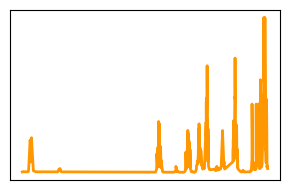

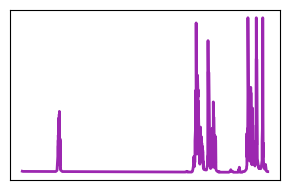

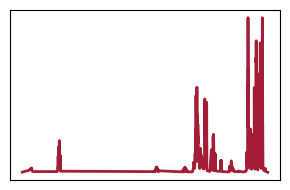

In [37]:
def plot_spectrum(df, color, figsize=(12, 3), filename=None):
    fig, ax = plt.subplots(figsize=figsize)
    y = df['intensity'] - np.percentile(df['intensity'], 5)
    ax.plot(df['ppm'], y, color=color, linewidth=2)
    ax.invert_xaxis()
    # no y ticks
    ax.set_yticks([])
    ax.set_xticks([])
    ax.tick_params(axis='both', which='major', labelsize=12)
    fig.tight_layout()
    if filename:
        fig.savefig(filename, format='svg', bbox_inches='tight')
    return fig, ax

plot_spectrum(df_borneol, color = "#FF9800", figsize=(3,2), filename='/Users/magdalenalederbauer/Code/MixSense/notebooks/borneol_spectrum.svg')
plot_spectrum(df_iso, color = "#9C27B0", figsize=(3,2), filename='/Users/magdalenalederbauer/Code/MixSense/notebooks/iso_spectrum.svg')
plot_spectrum(df_crude, color = "#a41d36", figsize=(3,2), filename='/Users/magdalenalederbauer/Code/MixSense/notebooks/crude_spectrum.svg')


(<Figure size 300x200 with 1 Axes>, <Axes: >)

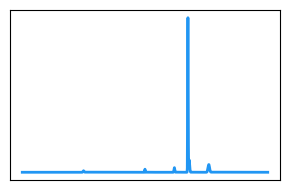

In [36]:
def make_synthetic_spectrum(peaks, ppm_axis=None):
    """peaks: list of (center_ppm, amplitude, width)"""
    if ppm_axis is None:
        ppm_axis = np.linspace(0, 10, 5000)
    intensity = np.zeros_like(ppm_axis)
    for center, amp, width in peaks:
        intensity += amp * np.exp(-0.5 * ((ppm_axis - center) / width) ** 2)
    return pd.DataFrame({'ppm': ppm_axis, 'intensity': intensity})

df_impurity = make_synthetic_spectrum([
    (3.2, 0.8e-3, 0.02),
    (3.25, 1e-2, 0.01),
    (2.4, 0.5e-3, 0.03),
    (3.8, 0.3e-3, 0.015),
    (5.0, 0.2e-3, 0.01),
    (7.5, 0.1e-3, 0.02),
])
plot_spectrum(df_impurity, color="#2196F3", figsize=(3,2), filename='/Users/magdalenalederbauer/Code/MixSense/notebooks/impurity_spectrum.svg')
